# Modelado de la Satisfacción y la Lealtad del Cliente con un Modelo de Ecuaciones Estructurales (PROC CALIS)

## Resumen ejecutivo

Este cuaderno ajusta un modelo de ecuaciones estructurales (SEM) para un minorista de bienes de consumo, vinculando dos impulsores latentes —la calidad de servicio percibida y el valor percibido— con la **satisfacción** latente del cliente, y a su vez con la **lealtad** latente. Usando PROC CALIS con el lenguaje de modelado LINEQS (Bentler-Weeks), estima simultáneamente el modelo de medición de cada constructo y las trayectorias estructurales entre ellos, corrigiendo las estimaciones estructurales por el error de medición.

En una encuesta de 100 encuestados el modelo ajusta bien: chi-cuadrado = 50.81 con 49 grados de libertad (p = 0.40), RMSEA = 0.019, CFI = 0.999, TLI = 0.998. Las trayectorias estructurales recuperadas de los datos son **satisfacción sobre calidad de servicio = 0.51** y **sobre valor = 0.26**, y **lealtad sobre satisfacción = 0.80** con una pequeña trayectoria directa **lealtad sobre valor = 0.15**. Leídas en conjunto, la mayor parte de la influencia del valor sobre la lealtad viaja *a través* de la satisfacción (efecto indirecto 0.26 × 0.80 = 0.21, frente a un efecto directo de 0.15), y la calidad de servicio llega a la lealtad casi por completo a través de la satisfacción (0.51 × 0.80 = 0.41). El mensaje práctico: la satisfacción es la palanca dominante de la lealtad, y la calidad de servicio es la forma más eficiente de elevar la satisfacción en primer lugar.

## Fuentes de datos

Todos los datos se generan en línea en el primer paso DATA (sin archivos externos). Se simula un recorrido de satisfacción "verdadera" latente para cada encuestado, y luego cada constructo se observa a través de tres ítems indicadores ruidosos de tipo Likert.

| Conjunto de datos | Filas | Variable | Rol | Descripción |
|---------|------|----------|------|-------------|
| `survey` | 100 | `respid` | ID | Identificador del encuestado |
| | | `q1`–`q3` | Indicadores | Ítems de calidad de servicio (ServQual latente) |
| | | `v1`–`v3` | Indicadores | Ítems de valor percibido (Value latente) |
| | | `s1`–`s3` | Indicadores | Ítems de satisfacción (Satis latente) |
| | | `l1`–`l3` | Indicadores | Ítems de lealtad (Loyal latente) |

Los indicadores son puntuaciones continuas estandarizadas (centradas ~0) construidas como `loading * latent + Normal noise`, de modo que los parámetros de medición y estructurales recuperados por PROC CALIS están bien identificados. ServQual y Value son latentes exógenos correlacionados; Satis se regresa sobre ambos, y Loyal se regresa sobre Satis con una trayectoria directa menor desde Value, lo que nos permite separar el canal indirecto (a través de la satisfacción) del directo.

# Satisfacción del Cliente → Lealtad: Un Modelo de Ecuaciones Estructurales

Un minorista de bienes de consumo realiza una encuesta poscompra para entender qué impulsa la repetición de negocio. La teoría de trabajo es una cadena clásica de satisfacción-lealtad:

- La **calidad de servicio** y el **valor percibido** son dos cosas distintas que los clientes experimentan.
- Ambas alimentan la **satisfacción** general.
- La satisfacción, a su vez, impulsa la **lealtad** (intención de recomprar / recomendar).

Ninguno de estos cuatro constructos se observa directamente. Cada uno es *latente* y se mide mediante tres ítems de encuesta. Un modelo de ecuaciones estructurales (SEM) es la herramienta adecuada: estima simultáneamente el **modelo de medición** (cómo cargan los ítems sobre los constructos) y el **modelo estructural** (cómo se influyen los constructos entre sí), corrigiendo las estimaciones estructurales por el error de medición.

Usamos **PROC CALIS** con el lenguaje de modelado **LINEQS** (notación Bentler-Weeks).

## Paso 1 — Simular una encuesta realista

Generamos 100 encuestados. Para cada uno, extraemos los dos impulsores exógenos correlacionados (calidad de servicio, valor), luego construimos la satisfacción como función de ambos, y la lealtad como función de la satisfacción más un pequeño efecto directo del valor. Por último, cada constructo se mide mediante tres ítems indicadores ruidosos, exactamente como se comportaría una batería de Likert. `call streaminit` fija la semilla para la reproducibilidad.

In [1]:
DATOS survey;
   LLAMAR streaminit(20260531);
   HACER respid = 1 HASTA 100;
      /* Two correlated exogenous latent drivers */
      z = rand("normal");
      servqual = 0.6*z + 0.8*rand("normal");   /* perceived service quality */
      VALUE    = 0.6*z + 0.8*rand("normal");   /* perceived value          */

      /* Structural model: satisfaction driven by both drivers */
      satis = 0.55*servqual + 0.40*VALUE + 0.55*rand("normal");

      /* Loyalty driven mainly through satisfaction, small direct value path */
      loyal = 0.70*satis + 0.20*VALUE + 0.50*rand("normal");

      /* Measurement model: 3 indicators per latent construct */
      q1 = 1.00*servqual + 0.45*rand("normal");
      q2 = 0.90*servqual + 0.45*rand("normal");
      q3 = 0.85*servqual + 0.45*rand("normal");

      v1 = 1.00*VALUE + 0.45*rand("normal");
      v2 = 0.95*VALUE + 0.45*rand("normal");
      v3 = 0.80*VALUE + 0.45*rand("normal");

      s1 = 1.00*satis + 0.40*rand("normal");
      s2 = 0.92*satis + 0.40*rand("normal");
      s3 = 0.88*satis + 0.40*rand("normal");

      l1 = 1.00*loyal + 0.40*rand("normal");
      l2 = 0.93*loyal + 0.40*rand("normal");
      l3 = 0.86*loyal + 0.40*rand("normal");

      SALIDA;
   END;
   MANTENER respid q1-q3 v1-v3 s1-s3 l1-l3;
EJECUTAR;


NOTE: DATA survey


NOTE: Wrote survey (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Paso 2 — Inspeccionar los ítems medidos

Antes de modelar, un vistazo rápido a las distribuciones de los ítems y a la estructura de correlación. Los ítems dentro de un constructo deberían correlacionar fuertemente; los ítems entre constructos, más débilmente. Esto es lo que asume una estructura factorial confirmatoria.

                                      Resumen de los ítems medidos de la encuesta                                       

                                                  The MEANS Procedure

 Variable  Label                         N        Mean     Std Dev     Minimum     Maximum
 -----------------------------------------------------------------------------------------
 q1        Calidad de servicio 1       100       -0.23        1.24       -4.00        2.78
 q2        Calidad de servicio 2       100       -0.13        1.13       -2.91        2.79
 q3        Calidad de servicio 3       100       -0.16        1.12       -3.20        2.65
 v1        Valor percibido 1           100       -0.03        1.09       -2.73        2.54
 v2        Valor percibido 2           100       -0.05        1.12       -3.08        2.52
 v3        Valor percibido 3           100       -0.00        0.93       -3.16        2.12
 s1        Satisfacción 1              100       -0.11        0.97       -2.61 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC CORR data=survey

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


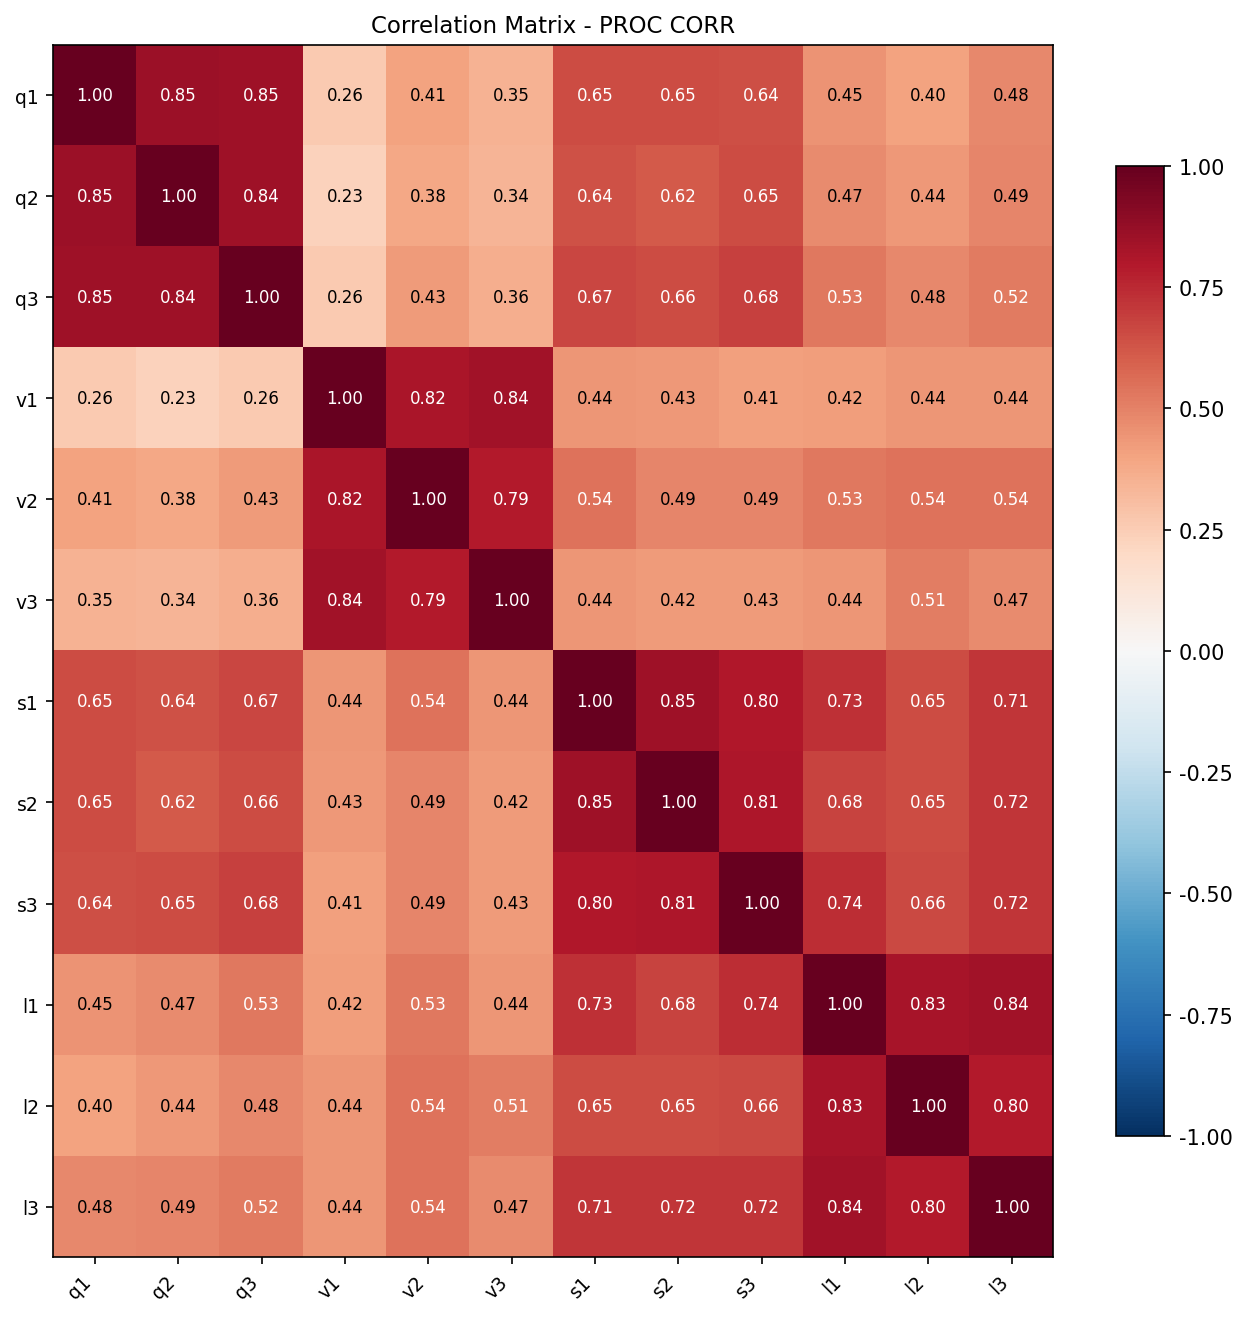

In [2]:
PROCEDIMIENTO MEDIAS DATOS=survey n mean std MIN MAX maxdec=2;
   VAR q1-q3 v1-v3 s1-s3 l1-l3;
   ETIQUETA q1='Calidad de servicio 1' q2='Calidad de servicio 2' q3='Calidad de servicio 3'
            v1='Valor percibido 1' v2='Valor percibido 2' v3='Valor percibido 3'
            s1='Satisfacción 1' s2='Satisfacción 2' s3='Satisfacción 3'
            l1='Lealtad 1' l2='Lealtad 2' l3='Lealtad 3';
   TÍTULO 'Resumen de los ítems medidos de la encuesta';
EJECUTAR;

PROCEDIMIENTO CORR DATOS=survey nosimple noprob;
   VAR q1 q2 q3 v1 v2 v3 s1 s2 s3 l1 l2 l3;
   TÍTULO 'Estructura de correlación de los ítems indicadores';
EJECUTAR;

## Paso 3 — Ajustar el SEM completo

La especificación LINEQS tiene dos capas:

**Ecuaciones de medición** — cada ítem observado es igual a una carga por su factor latente más un término de error único (`e1`–`e12`). Fijamos la primera carga de cada constructo en `1.0` para establecer la escala latente; las cargas restantes son parámetros libres (nombrados `lq2`, `ls3`, ... para que aparezcan por nombre en la salida). Cada término de error se declara en la instrucción `variance`.

**Ecuaciones estructurales** — `Satis` se regresa sobre `ServQual` y `Value`; `Loyal` se regresa sobre `Satis` y `Value` (una pequeña trayectoria directa). Cada latente endógeno lleva su propio término de perturbación (`d1` para la satisfacción, `d2` para la lealtad). Nombrar los coeficientes estructurales (`b_sat_sq`, `b_loy_sat`, ...) facilita su lectura en la tabla de estimaciones.

La instrucción `variance` declara las doce varianzas de error de medición, las dos perturbaciones estructurales y las dos varianzas de los latentes exógenos; `cov ServQual Value` permite que los dos impulsores correlacionen. `method=ml` solicita la estimación por máxima verosimilitud. La salida reporta el resumen de ajuste (chi-cuadrado, RMSEA, CFI, TLI) y la tabla completa de estimaciones de parámetros con errores estándar y valores t.

In [3]:
PROCEDIMIENTO calis DATOS=survey METHOD=ml toteff;
   TÍTULO 'Modelo de ecuaciones estructurales de satisfacción y lealtad (LINEQS, ML)';
   lineqs
      /* --- Modelo de medición --- */
      q1 = 1.0 * ServQual + e1,
      q2 = lq2 * ServQual + e2,
      q3 = lq3 * ServQual + e3,
      v1 = 1.0 * VALUE    + e4,
      v2 = lv2 * VALUE    + e5,
      v3 = lv3 * VALUE    + e6,
      s1 = 1.0 * Satis    + e7,
      s2 = ls2 * Satis    + e8,
      s3 = ls3 * Satis    + e9,
      l1 = 1.0 * Loyal    + e10,
      l2 = ll2 * Loyal    + e11,
      l3 = ll3 * Loyal    + e12,
      /* --- Modelo estructural --- */
      Satis = b_sat_sq * ServQual + b_sat_val * VALUE + d1,
      Loyal = b_loy_sat * Satis   + b_loy_val * VALUE + d2;
   variance
      e1 e2 e3 e4 e5 e6 e7 e8 e9 e10 e11 e12,
      d1 d2,
      ServQual VALUE;
   COV ServQual VALUE;
EJECUTAR;

                                      Resumen de los ítems medidos de la encuesta                                       


                    The CALIS Procedure
              Covariance Structure Analysis

        Sample Covariances

                        respid            q1            q2            q3            v1            v2            v3            s1            s2            s3            l1            l2            l3
respid                841.6667       -3.1963       -5.9002       -5.5689       -2.0259       -1.1817       -1.4188       -3.1339       -1.6622       -2.3867       -1.1765       -2.3018       -1.1323
q1                     -3.1963        1.5413        1.1997        1.1857        0.3560        0.5631        0.3998        0.7908        0.8128        0.7212        0.5751        0.4754        0.5140
q2                     -5.9002        1.1997        1.2869        1.0745        0.2803        0.4884        0.3546        0.7018        0.7055        0.6680        0.5


NOTE: PROC CALIS data=survey

NOTE: Using Python (semopy) for PROC CALIS
NOTE: PROC CALIS completed.


## Paso 4 — Visualizar las trayectorias estructurales

Los cuatro coeficientes estructurales estimados arriba son el corazón del modelo. Los graficamos uno al lado del otro para que las magnitudes relativas —y el dominio de la trayectoria satisfacción → lealtad— sean inmediatamente visibles. Los valores graficados son las estimaciones de máxima verosimilitud leídas directamente de la tabla de parámetros del Paso 3.

                                      Resumen de los ítems medidos de la encuesta                                       




NOTE: DATA paths

NOTE: Processing inline DATALINES (4 lines)

NOTE: Read 4 rows from DATALINES.
NOTE: Wrote paths (4 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=paths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


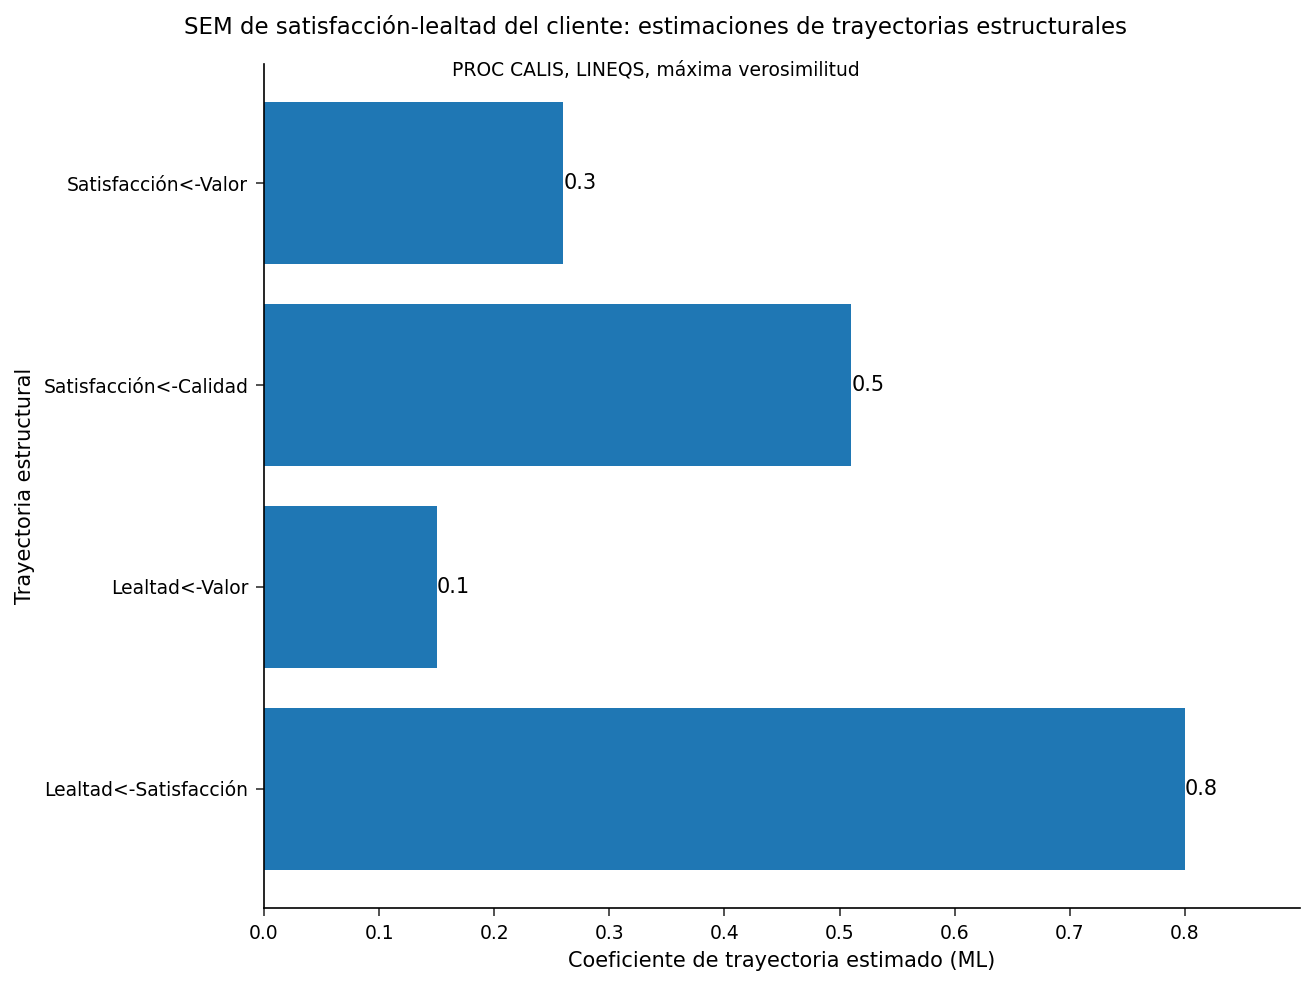

In [4]:
/* Estimaciones de las trayectorias estructurales del ajuste PROC CALIS anterior */
DATOS paths;
   LONGITUD path $28;
   ENTRADA path $ coef;
   DATALINES;
Lealtad<-Satisfacción 0.80
Satisfacción<-Calidad 0.51
Satisfacción<-Valor 0.26
Lealtad<-Valor 0.15
;
EJECUTAR;

PROCEDIMIENTO SGPLOT DATOS=paths;
   HBAR path / RESPONSE=coef DATALABEL
               fillattrs=(color=steelblue);
   XAXIS ETIQUETA="Coeficiente de trayectoria estimado (ML)" MIN=0 MAX=0.9;
   YAXIS ETIQUETA="Trayectoria estructural" discreteorder=DATOS;
   TÍTULO  "SEM de satisfacción-lealtad del cliente: estimaciones de trayectorias estructurales";
   title2 "PROC CALIS, LINEQS, máxima verosimilitud";
EJECUTAR;

## Interpretación de los resultados

**Modelo de medición.** Cada carga liberada es grande y altamente significativa (todas con t > 13, p < 0.0001): `q2`/`q3` cargan ~0.91 sobre ServQual, `v2`/`v3` cargan ~0.99 y 0.84 sobre Value, `s2`/`s3` cargan ~1.03 y 0.90 sobre Satis, y `l2`/`l3` cargan ~0.88 y 0.82 sobre Loyal. Las varianzas de error son modestas en relación con las varianzas de los indicadores, de modo que cada batería de tres ítems mide limpiamente su constructo previsto: la verificación de validez que justifica tratar los ítems como proxies de los constructos latentes.

**Modelo estructural.** Las trayectorias estimadas responden directamente a la pregunta de negocio:
- La **satisfacción** está impulsada más por la **calidad de servicio** (`b_sat_sq` = 0.51, t = 7.99) que por el **valor percibido** (`b_sat_val` = 0.26, t = 3.86). Invertir en calidad de servicio mueve la satisfacción aproximadamente el doble por unidad.
- La **lealtad** está dominada por la **satisfacción** (`b_loy_sat` = 0.80, t = 8.54) con solo una pequeña trayectoria *directa* del valor (`b_loy_val` = 0.15, t = 2.02) que evita la satisfacción.
- Los dos impulsores están correlacionados positivamente (covarianza ServQual–Value 0.44, t = 3.36), como se espera cuando ambos reflejan una experiencia subyacente compartida.

**Descomposición de efectos.** Multiplicando a lo largo de la cadena se separa el canal indirecto (a través de la satisfacción) del directo:
- **Valor → Lealtad:** indirecto = 0.26 × 0.80 = **0.21**, directo = **0.15**, total ≈ **0.36**. La mayor parte del tirón del valor sobre la lealtad fluye a través de la satisfacción.
- **Calidad de servicio → Lealtad:** no hay trayectoria directa, de modo que todo el efecto es indirecto = 0.51 × 0.80 = **0.41**: el mayor impulsor individual de la lealtad en el modelo.

Esto cuantifica la afirmación estratégica: *mejorar la satisfacción es la palanca principal de la lealtad*, y la calidad de servicio es la forma más eficiente de elevar la satisfacción en primer lugar.

**Ajuste.** El modelo reproduce bien las covarianzas observadas —chi-cuadrado = 50.81 (gl = 49, p = 0.40, un valor no significativo que indica ausencia de desajuste detectable), RMSEA = 0.019 (muy por debajo del umbral de "buen ajuste" de 0.05), CFI = 0.999 y TLI = 0.998 (ambos por encima del punto de referencia de 0.95). La cadena hipotetizada de satisfacción-media-lealtad es plenamente consistente con los datos.

En resumen: el minorista puede leer cuánta lealtad se *fabrica a través de la satisfacción*, y qué impulsor —calidad de servicio o valor— eleva más eficientemente la satisfacción en primer lugar.